In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


##Load data

In [2]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/Suicide_Detection 4.csv")

print(df.head())
print(df['class'].value_counts())
print(df.isnull().sum())

   Unnamed: 0                                               text        class
0           2  Ex Wife Threatening SuicideRecently I left my ...      suicide
1           3  Am I weird I don't get affected by compliments...  non-suicide
2           4  Finally 2020 is almost over... So I can never ...  non-suicide
3           8          i need helpjust help me im crying so hard      suicide
4           9  I’m so lostHello, my name is Adam (16) and I’v...      suicide
class
suicide        116037
non-suicide    116037
Name: count, dtype: int64
Unnamed: 0    0
text          0
class         0
dtype: int64


##Cleaning data

In [3]:
import re
import numpy as np
import pandas as pd

pd.set_option('future.no_silent_downcasting', True)

df = df.drop_duplicates()

# Drop rows where text is missing
df = df.dropna(subset=['text'])

# Normalize labels to 0/1
# Adapt this to your actual labels
df['class'] = df['class'].replace({
    'suicide': 1,
    'non-suicide': 0
})
df['class'] = df['class'].astype(int)

# Simple text cleaning function
def clean_text(text):
    text = str(text)
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", " ", text)   # remove urls
    text = re.sub(r"[^a-zA-Z\s]", " ", text)      # keep letters & spaces
    text = re.sub(r"\s+", " ", text).strip()      # remove extra spaces
    return text

df['clean_text'] = df['text'].apply(clean_text)

df.head()

,Unnamed: 0,text,class,clean_text
0,2,Ex Wife Threatening SuicideRecently I left my ...,1,ex wife threatening suiciderecently i left my ...
1,3,Am I weird I don't get affected by compliments...,0,am i weird i don t get affected by compliments...
2,4,Finally 2020 is almost over... So I can never ...,0,finally is almost over so i can never hear has...
3,8,i need helpjust help me im crying so hard,1,i need helpjust help me im crying so hard
4,9,"I’m so lostHello, my name is Adam (16) and I’v...",1,i m so losthello my name is adam and i ve been...


##Feature Engineering

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

X = df['clean_text']
y = df['class']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# TF-IDF vectorizer
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_df=0.95,
    min_df=5,
    max_features=10000    # limit size
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

X_train_tfidf.shape, X_test_tfidf.shape

((185659, 10000), (46415, 10000))

##Model Building

In [5]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    n_jobs=-1
)

model.fit(X_train_tfidf, y_train)


LogisticRegression(class_weight='balanced', max_iter=1000, n_jobs=-1)

##Evaluation, Confusion Matrix, ROC Curve

In [6]:
from sklearn.metrics import classification_report, accuracy_score

y_pred = model.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))


Accuracy: 0.9388128837660239

Classification Report:
              precision    recall  f1-score   support

           0     0.9308    0.9481    0.9394     23208
           1     0.9471    0.9295    0.9382     23207

    accuracy                         0.9388     46415
   macro avg     0.9390    0.9388    0.9388     46415
weighted avg     0.9390    0.9388    0.9388     46415



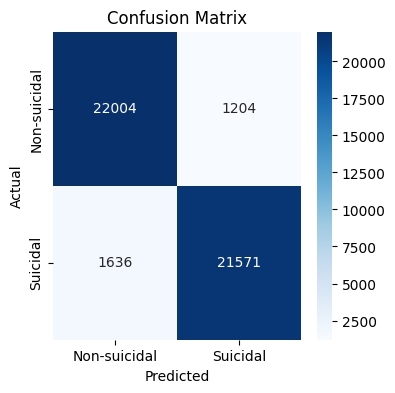

In [7]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(4,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Non-suicidal', 'Suicidal'],
            yticklabels=['Non-suicidal', 'Suicidal'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
print("Cell executed")


Cell executed


AUC: 0.9834054452184139


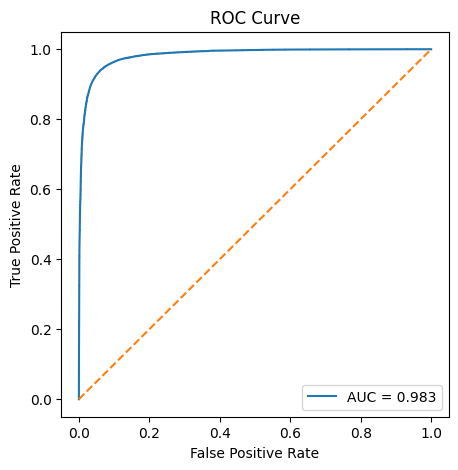

In [8]:
from sklearn.metrics import roc_curve, roc_auc_score

# For logistic regression:
y_scores = model.predict_proba(X_test_tfidf)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_scores)
auc = roc_auc_score(y_test, y_scores)
print("AUC:", auc)

plt.figure(figsize=(5,5))
plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


In [9]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(class_weight='balanced')

svm_model.fit(X_train_tfidf, y_train)
y_pred_svm = svm_model.predict(X_test_tfidf)

print(classification_report(y_test, y_pred_svm, digits=4))


              precision    recall  f1-score   support

           0     0.9322    0.9469    0.9395     23208
           1     0.9461    0.9311    0.9385     23207

    accuracy                         0.9390     46415
   macro avg     0.9391    0.9390    0.9390     46415
weighted avg     0.9391    0.9390    0.9390     46415



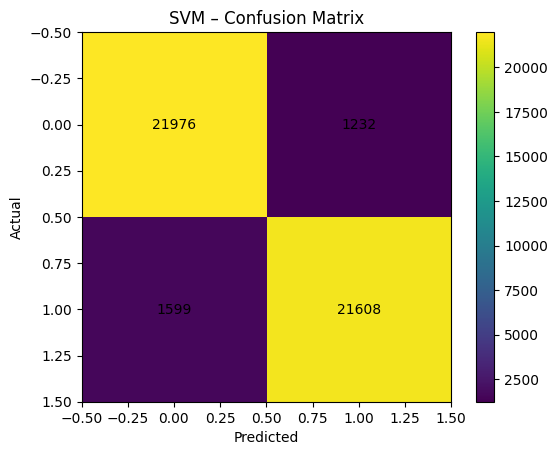

In [11]:
cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure()
plt.imshow(cm_svm)
plt.title("SVM – Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm_svm[i, j], ha="center", va="center")

plt.show()


In [16]:
from sklearn.metrics import classification_report
import pandas as pd


report_lr = classification_report(y_test, y_pred, output_dict=True, digits=4)
report_svm = classification_report(y_test, y_pred_svm, output_dict=True, digits=4)


comparison_data = {
    'Metric': [
        'Accuracy',
        'Precision (Non-suicidal)',
        'Recall (Non-suicidal)',
        'F1-score (Non-suicidal)',
        'Precision (Suicidal)',
        'Recall (Suicidal)',
        'F1-score (Suicidal)'
    ],
    'Logistic Regression': [
        report_lr['accuracy'],
        report_lr['0']['precision'],
        report_lr['0']['recall'],
        report_lr['0']['f1-score'],
        report_lr['1']['precision'],
        report_lr['1']['recall'],
        report_lr['1']['f1-score']
    ],
    'LinearSVC': [
        report_svm['accuracy'],
        report_svm['0']['precision'],
        report_svm['0']['recall'],
        report_svm['0']['f1-score'],
        report_svm['1']['precision'],
        report_svm['1']['recall'],
        report_svm['1']['f1-score']
    ]
}

comparison_df = pd.DataFrame(comparison_data)
display(comparison_df.round(4))


,Metric,Logistic Regression,LinearSVC
0,Accuracy,0.9388,0.9390
1,Precision (Non-suicidal),0.9308,0.9322
2,Recall (Non-suicidal),0.9481,0.9469
3,F1-score (Non-suicidal),0.9394,0.9395
4,Precision (Suicidal),0.9471,0.9461
5,Recall (Suicidal),0.9295,0.9311
6,F1-score (Suicidal),0.9382,0.9385


In [19]:
def test_text(text):

    cleaned = clean_text(text)


    vector = tfidf.transform([cleaned])


    prediction = model.predict(vector)[0]


    probability = model.predict_proba(vector)[0][1]

    if prediction == 1:
        label = "SUICIDAL"
    else:
        label = "NON-SUICIDAL"

    print("Text:", text)
    print("Prediction:", label)
    print("Suicidal probability:", round(probability, 3))

In [20]:
test_text("I feel happy and motivated today")
test_text("I am tired of everything and feel hopeless")
test_text("Life is meaningless and I want to end it")
test_text("Today was stressful but I will try again tomorrow")


Text: I feel happy and motivated today
Prediction: NON-SUICIDAL
Suicidal probability: 0.101
Text: I am tired of everything and feel hopeless
Prediction: SUICIDAL
Suicidal probability: 0.937
Text: Life is meaningless and I want to end it
Prediction: SUICIDAL
Suicidal probability: 0.998
Text: Today was stressful but I will try again tomorrow
Prediction: NON-SUICIDAL
Suicidal probability: 0.177


In [22]:
test_text("My wife is threatening to kill")

Text: My wife is threatening to kill
Prediction: SUICIDAL
Suicidal probability: 0.969


In [23]:
test_text("Life is soo full of trouble")

Text: Life is soo full of trouble
Prediction: SUICIDAL
Suicidal probability: 0.55
